In [2]:
using Pkg
using CSV
using DataFrames
using Polynomials
using CairoMakie
using Statistics

In [86]:
include("D:/01 Projekt/03 Programm/Rini aktuell/Rini/src/TIRA.jl")

Main.TIRA

## Plots


### fig1

In [93]:
# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

Axis with 0 plots:


In [ ]:
# Plot the first curve with lines and markers
fig50 = Figure(resolution = (1000, 600))
font=24
ax1_50= Axis(fig50[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_50 = Axis(fig50[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

## Proben Geometrie

In [94]:
## Geometrie
w=10*1e-3 # Width
t=15*1e-6 # thickness
l=75*1e-3 # length
As=w*t    # stress section

1.5e-7

## Temperature Raum

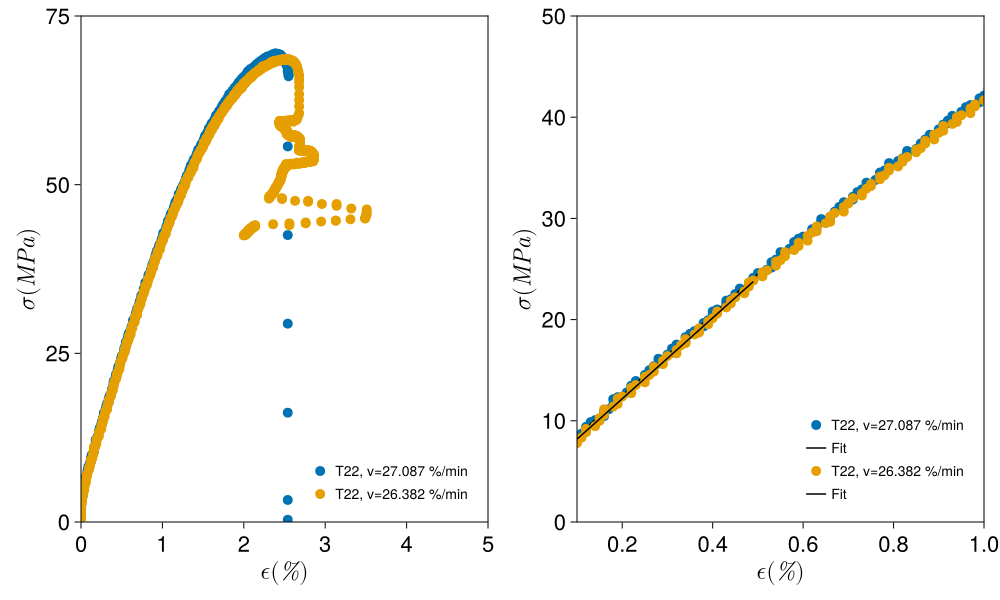

In [95]:

#### Raum T

BaseName="AP5ZK04/251103-"
name="251103-"

DataProperties=[]

for i in [1 2]
        
        df=TIRA.computeStressStrain(BaseName,name,i,22,As)
        df=TIRA.filter_range(df,"dL_ORG",0,10)
        properties, df_fit=TIRA.computeProperties(df,[0.1 0.5],[0 100])
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T22, v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        
        limits!(ax1_Raum, 0, 5, 0, 75)


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T22, v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:StrainFit],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, 0.1, 1,0,50)

        push!(DataProperties,properties)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [85]:
df_DataProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,4.18143,20.9205,251103-1,2.39,"[0.11, 0.5]",0.625591,22,4.00365,69.4667,24.6,27.087
2,4.94192,19.3676,251103-2,2.53,"[0.1, 0.49]",0.689764,22,3.9936,68.6667,23.8667,26.3818


## Temperature 50

In [ ]:
####  T 50

#### Gesamtgruppe um 50 °C

BaseName="AP5ZK04/251103-"
name="251103-"

DataProperties=[]
df_Data=[]

   for i in [3,4,5,6,7]

        df=TIRA.computeStressStrain(BaseName,name,i,50,As)
        df=TIRA.filter_range(df,"dL_ORG",0,10)
        properties=TIRA.computeProperties(df,[0.1 0.5],[0 100])
        push!(DataProperties,properties)
        push!(df_Data,df)

        Makie.scatter!(ax1_50 ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T22, v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        
        limits!(ax1_50, 0, 5, 0, 75)


        Makie.scatter!(ax2_50 ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T22, v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_50 ,df_fit[!,:StrainFit],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_50, 0.1, 1,0,50)

        push!(DataProperties,properties)


    end

    df_DataProperties=DataFrame(DataProperties)



Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,8.5877,19.685,251103-03,2.54,"[0.1, 0.5]",1.35141,50,1.13151,26.1333,5.86667,13.1678
2,204.837,18.5328,251103-04,2.59,"[0.1, 0.48]",11.4385,50,2.40571,26.5333,11.2,3.68662
3,20.4692,22.7273,251103-05,2.2,"[0.1, 0.5]",2.37483,50,2.40932,31.2667,11.6,8.58576
4,2.70621,22.6244,251103-06,2.21,"[0.11, 0.5]",1.08816,50,2.41445,36.4667,15.0,33.1429
5,6.81288,21.645,251103-07,2.31,"[0.1, 0.5]",0.805889,50,2.64315,35.7333,14.3333,24.4739


## Temperaure 100

In [37]:
####  T 100

#### Gesamtgruppe um 100 °C

BaseName="AP5ZK04/251103-"
name="251103-"

DataProperties=[]
df_Data=[]

   for i in [8,9,10]

        df=TIRA.computeStressStrain(BaseName,name,i,100,As)
        df=TIRA.filter_range(df,"dL_ORG",0,10)
        properties=TIRA.computeProperties(df,[1.2 2],[0 100])
        push!(DataProperties,properties)
        push!(df_Data,df)

    end

    df_DataProperties=DataFrame(DataProperties)

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,7.86049,54.4959,251103-8,3.67,"[1.2, 2.0]",2.48205,100,1.65069,29.2667,25.6667,20.2033
2,13.7458,93.0233,251103-9,2.15,"[1.2, 2.0]",16.5943,100,0.160578,24.8,24.2667,1.18137
3,3.12264,71.8412,251103-10,2.77,"[1.2, 1.99]",0.869729,100,1.32388,25.5333,19.8,25.0633
